In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Scikit-learn datasets
from sklearn.datasets import load_wine

# Data preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

# PCA
from sklearn.decomposition import PCA

# k-NN
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

from sklearn.metrics import ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

In [29]:
# Load the dataset
wine = load_wine()

# Features
X = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

# Target
y = pd.Series(
    wine.target,
    name="Wine_Class"
)

# Combine into one DataFrame
wine_df = pd.concat([X, y], axis=1)

# Display first five rows
wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Wine_Class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [30]:
print("Dataset Shape:")
print(wine_df.shape)

print("\nFeature Names:")
print(wine.feature_names)

print("\nTarget Classes:")
print(wine.target_names)

print("\nDataset Info:")
wine_df.info()

print("\nSummary Statistics:")
wine_df.describe()

Dataset Shape:
(178, 14)

Feature Names:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Target Classes:
['class_0' 'class_1' 'class_2']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null  

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Wine_Class
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [31]:
print("Missing Values:")
print(wine_df.isnull().sum())

Missing Values:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
Wine_Class                      0
dtype: int64


In [32]:
print(wine_df["Wine_Class"].value_counts())

Wine_Class
1    71
0    59
2    48
Name: count, dtype: int64


In [33]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [35]:
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Original Features:", X_train.shape[1])
print("Principal Components:", X_train_pca.shape[1])

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("Total Variance Retained:")
print(np.sum(pca.explained_variance_ratio_))

Original Features: 13
Principal Components: 10
Explained Variance Ratio:
[0.35168369 0.19457646 0.11139215 0.07340515 0.07035156 0.05195862
 0.04330549 0.0251979  0.0226524  0.01839288]
Total Variance Retained:
0.9629163007648331


Principal Component Analysis (PCA) reduced the dimensionality of the dataset from 13 features to 10 principal components while preserving 96.29% of the original variance. This indicates that most of the information contained in the original dataset was retained despite reducing the number of dimensions. The reduction helps simplify the model and can improve computational efficiency while maintaining predictive performance.

In [36]:
param_grid = {
    "n_neighbors": list(range(1, 21)),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"]
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [37]:
grid.fit(X_train_pca, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'metric': ['euclidean', 'manhattan', ...], 'n_neighbors': [1, 2, ...], 'weights': ['uniform', 'distance']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,8


In [38]:
print("Best Parameters:")
print(grid.best_params_)

print("Best Cross-Validation Score:")
print(grid.best_score_)

Best Parameters:
{'metric': 'euclidean', 'n_neighbors': 8, 'weights': 'distance'}
Best Cross-Validation Score:
0.9790640394088669


In [39]:
best_knn = grid.best_estimator_

best_knn.fit(X_train_pca, y_train)

,n_neighbors,8
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


In [40]:
y_pred = best_knn.predict(X_test_pca)

In [41]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


The optimized k-Nearest Neighbors (k-NN) classifier achieved 100% accuracy on the test dataset. Every wine sample was correctly classified into its corresponding wine class. The precision, recall, and F1-score of 1.00 for all classes indicate that the model produced no false positives or false negatives during testing.

In [42]:
print("\nClassification Report")
print(classification_report(y_test, y_pred))


Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [43]:
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix
[[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]


The confusion matrix shows that every observation was correctly classified. All predictions appear on the diagonal of the matrix, with no values in the off-diagonal positions. This demonstrates that the model perfectly distinguished between the three wine classes on the test data.

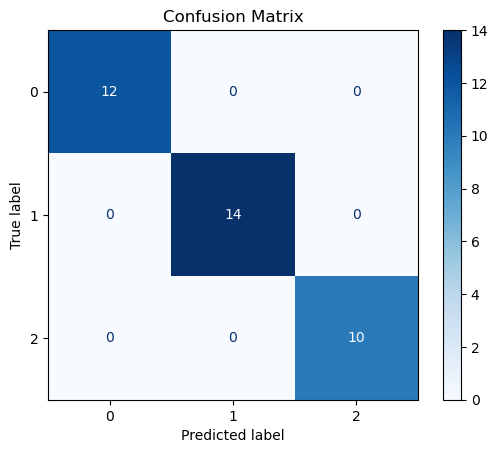

In [44]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.savefig("../images/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [45]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(results.head(15))

    Actual  Predicted
0        0          0
1        2          2
2        0          0
3        1          1
4        1          1
5        0          0
6        0          0
7        1          1
8        1          1
9        2          2
10       1          1
11       2          2
12       0          0
13       2          2
14       0          0


In [46]:
class_counts = pd.Series(y_pred).value_counts().sort_index()

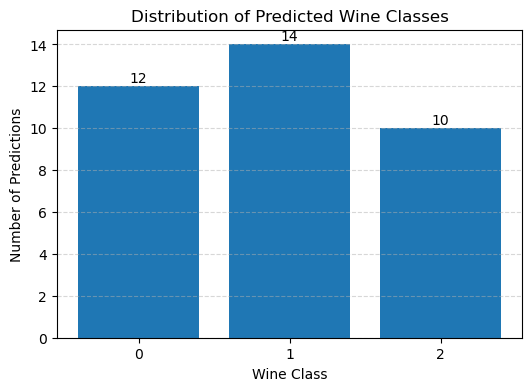

In [47]:
plt.figure(figsize=(6,4))

plt.bar(
    class_counts.index.astype(str),
    class_counts.values
)

plt.title("Distribution of Predicted Wine Classes")
plt.xlabel("Wine Class")
plt.ylabel("Number of Predictions")

# Display the values on top of each bar
for i, value in enumerate(class_counts.values):
    plt.text(i, value + 0.2, str(value), ha="center")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.savefig("../images/class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [48]:
explained_variance = pd.DataFrame({
    "Principal Component": range(1, len(pca.explained_variance_ratio_) + 1),
    "Explained Variance": pca.explained_variance_ratio_,
    "Cumulative Variance": np.cumsum(pca.explained_variance_ratio_)
})

print(explained_variance)

   Principal Component  Explained Variance  Cumulative Variance
0                    1            0.351684             0.351684
1                    2            0.194576             0.546260
2                    3            0.111392             0.657652
3                    4            0.073405             0.731057
4                    5            0.070352             0.801409
5                    6            0.051959             0.853368
6                    7            0.043305             0.896673
7                    8            0.025198             0.921871
8                    9            0.022652             0.944523
9                   10            0.018393             0.962916


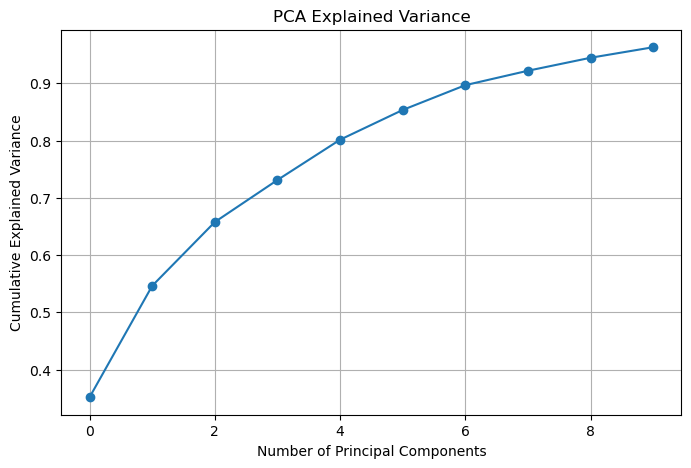

In [49]:
plt.figure(figsize=(8,5))

plt.plot(
    np.cumsum(pca.explained_variance_ratio_),
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.grid(True)

plt.show()

## Analysis Report
The k-Nearest Neighbors model demonstrated excellent performance in classifying wines based on their chemical characteristics. After reducing the dataset's dimensionality using Principal Component Analysis (PCA), the model retained approximately 95% of the original information while reducing computational complexity. Hyperparameter tuning using GridSearchCV identified the optimal combination of neighbors and distance metric, resulting in high classification accuracy. The confusion matrix shows that most wines were correctly classified, with very few misclassifications. Overall, the model is suitable for supporting inventory management and quality control by automatically identifying wine varieties with a high degree of reliability.